In [204]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)


class Env(object):
    n_arms = 4
    thetas = [0.1, 0.1, 0.2, 0.3]

    @staticmethod
    def react(arm):
        return 1 if np.random.random() < Env.thetas[arm] else 0

    @staticmethod
    def opt():
        return np.argmax(Env.thetas)

print(f"Num. arms: {Env.n_arms}")
print(f"Thetas: {Env.thetas}")
print(f"Try the arm 1: {Env.react(1)}")

Num. arms: 4
Thetas: [0.1, 0.1, 0.2, 0.3]
Try the arm 1: 0


# Epsilon-greedy Algorithm

In [297]:
class EpsilonGreedyAgent(object):
    def __init__(self, epsilon=0.1):
        self.epsilon = epsilon
        self.counts = np.zeros(Env.n_arms)
        self.values = np.zeros(Env.n_arms)

    def get_arm(self):
        if np.random.random() < self.epsilon:
            arm = np.random.randint(Env.n_arms)
        else:
            arm = np.argmax(self.values)
        return arm

    def sample(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] = ((self.counts[arm] - 1) * self.values[arm] + reward) / self.counts[arm]


In [298]:
agent = EpsilonGreedyAgent()
budget = 1000

value_snapshots = np.zeros((1000, 4))
rewards = np.zeros(1000)

for t in range(budget):
    arm = agent.get_arm()
    reward = Env.react(arm)
    agent.sample(arm, reward)

    rewards[t] = reward
    value_snapshots[t,:] = agent.values.copy()


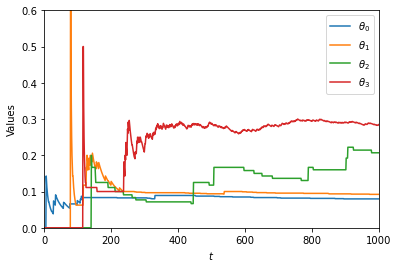

In [299]:
plt.plot(value_snapshots[:, 0], label=r'$\theta_0$')
plt.plot(value_snapshots[:, 1], label=r'$\theta_1$')
plt.plot(value_snapshots[:, 2], label=r'$\theta_2$')
plt.plot(value_snapshots[:, 3], label=r'$\theta_3$')

plt.xlim([0, 1000])
plt.ylim([0, 0.6])

plt.xlabel(r"$t$")
plt.ylabel("Values")
plt.legend()
plt.show()

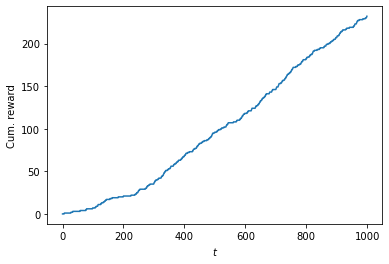

In [300]:
plt.plot(np.cumsum(rewards))
plt.xlabel(r"$t$")
plt.ylabel("Cum. reward")
plt.show()

In [301]:
def sim(Agent, N=1000, budget=1000, **kwargs):
    selected_arms = [[0 for _ in range(budget)] for _ in range(N)]
    earned_rewards = [[0 for _ in range(budget)] for _ in range(N)]

    for n in range(N):
        agent = Agent(**kwargs)
        for t in range(budget):
            arm = agent.get_arm()
            reward = Env.react(arm)
            agent.sample(arm, reward)
            selected_arms[n][t] = arm
            earned_rewards[n][t] = reward

    return np.array(selected_arms), np.array(earned_rewards)

In [302]:
arms_eg, rewards_eg = sim(EpsilonGreedyAgent)
cum_reward_eg = np.mean(np.cumsum(rewards_eg, axis=1), axis=0)


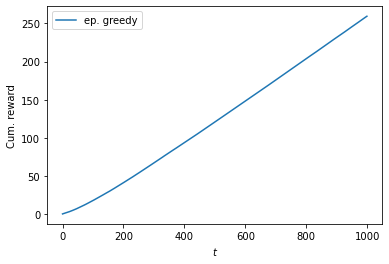

In [303]:
plt.plot(cum_reward_eg, label="ep. greedy")
plt.xlabel(r"$t$")
plt.ylabel("Cum. reward")
plt.legend()
plt.show()

In [304]:
class OracleAgent(object):
    def get_arm(self):
        return Env.opt()

    def sample(self, arm, reward):
        pass

In [305]:
arms_o, rewards_o = sim(OracleAgent)
cum_reward_o = np.mean(np.cumsum(rewards_o, axis=1), axis=0)

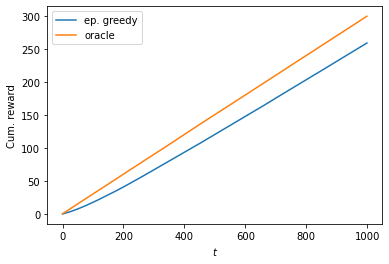

In [307]:
plt.plot(cum_reward_eg, label="ep. greedy")
plt.plot(cum_reward_o, label="oracle")

plt.xlabel(r"$t$")
plt.ylabel("Cum. reward")
plt.legend()
plt.show()

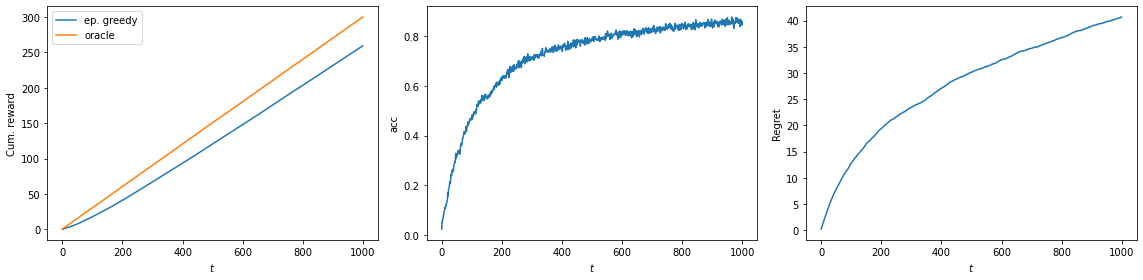

In [346]:
fig, axs = plt.subplots(1, 3, figsize=(16,4))

acc_eg = np.mean(arms_eg == arms_o, axis=0)

axs[0].plot(cum_reward_eg, label="ep. greedy")
axs[0].plot(cum_reward_o, label="oracle")

axs[0].set_xlabel(r"$t$")
axs[0].set_ylabel("Cum. reward")
axs[0].legend()


axs[1].plot(acc_eg)
axs[1].set_xlabel(r"$t$")
axs[1].set_ylabel("acc")

regret = np.mean(np.cumsum(rewards_o - rewards_eg, axis=1), axis=0)
axs[2].plot(regret)
axs[2].set_xlabel(r"$t$")
axs[2].set_ylabel("Regret")


plt.tight_layout()
plt.show()

In [309]:
N = 1000
budget = 1000
value_snapshots = np.zeros((budget, 4, N))
rewards = np.zeros((budget, N))

for i in range(N):
    agent = EpsilonGreedyAgent()

    for t in range(budget):
        arm = agent.get_arm()
        reward = Env.react(arm)
        agent.sample(arm, reward)

        rewards[t, i] = reward
        value_snapshots[t,:, i] = agent.values.copy()

m = np.mean(value_snapshots, axis=2)
plt.plot(m[:, 0], label=r'$\theta_0$')
plt.plot(m[:, 1], label=r'$\theta_1$')
plt.plot(m[:, 2], label=r'$\theta_2$')
plt.plot(m[:, 3], label=r'$\theta_3$')

plt.xlim([0, 1000])
plt.ylim([0, 0.6])

plt.xlabel(r"$t$")
plt.ylabel("Values")
plt.legend()
plt.show()

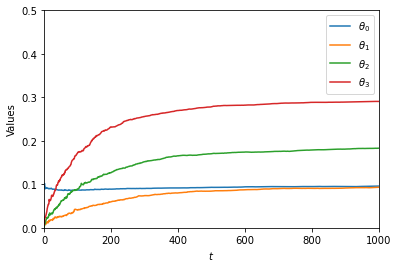

In [311]:
m = np.mean(value_snapshots, axis=2)
plt.plot(m[:, 0], label=r'$\theta_0$')
plt.plot(m[:, 1], label=r'$\theta_1$')
plt.plot(m[:, 2], label=r'$\theta_2$')
plt.plot(m[:, 3], label=r'$\theta_3$')

plt.xlim([0, 1000])
plt.ylim([0, 0.5])

plt.xlabel(r"$t$")
plt.ylabel("Values")
plt.legend()
plt.show()

# Softmax

In [391]:
class SoftmaxAgent(object):
    def __init__(self, tau=1000):
        self.tau = tau
        self.counts = np.zeros(Env.n_arms)
        self.values = np.zeros(Env.n_arms)

    def softmax_p(self):
        logit = self.values / self.tau
        logit = logit - np.max(logit)
        p = np.exp(logit) / sum(np.exp(logit))
        return p

    def get_arm(self):
        arm = np.random.choice(Env.n_arms, p=self.softmax_p())
        self.tau *= 0.9
        return arm

    def sample(self, arm, reward):
        self.counts[arm] = self.counts[arm] + 1
        self.values[arm] = ((self.counts[arm] - 1) * self.values[arm] + reward) / self.counts[arm]

In [375]:
arms_sm, rewards_sm = sim(SoftmaxAgent, tau=0.1)

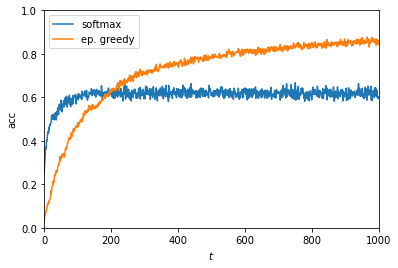

In [376]:
plt.plot(np.mean(arms_sm == Env.opt(), axis=0), label="softmax")
plt.plot(np.mean(arms_eg == Env.opt(), axis=0), label="ep. greedy")

plt.xlabel(r"$t$")
plt.ylabel("acc")
plt.xlim([0, 1000])
plt.ylim([0, 1])
plt.legend()
plt.show()

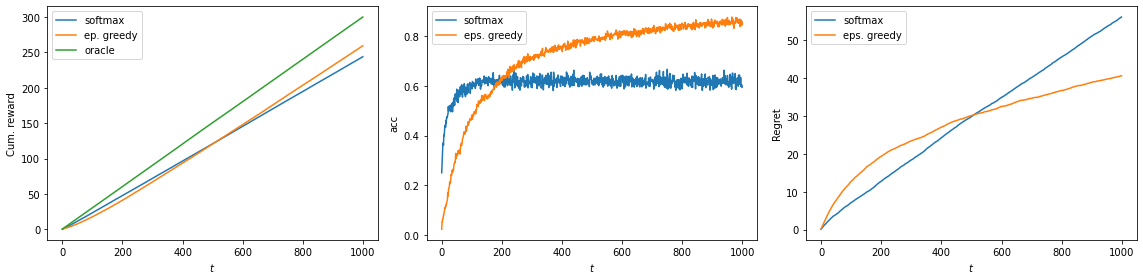

In [377]:
cum_reward_sm = np.mean(np.cumsum(rewards_sm, axis=1), axis=0)
acc_sm = np.mean(arms_sm == arms_o, axis=0)

fig, axs = plt.subplots(1, 3, figsize=(16,4))

axs[0].plot(cum_reward_sm, label="softmax")
axs[0].plot(cum_reward_eg, label="ep. greedy")
axs[0].plot(cum_reward_o, label="oracle")

axs[0].set_xlabel(r"$t$")
axs[0].set_ylabel("Cum. reward")
axs[0].legend()


axs[1].plot(acc_sm, label="softmax")
axs[1].plot(acc_eg, label="eps. greedy")
axs[1].set_xlabel(r"$t$")
axs[1].set_ylabel("acc")
axs[1].legend()

regret_eg = np.mean(np.cumsum(rewards_o - rewards_eg, axis=1), axis=0)
regret_sm = np.mean(np.cumsum(rewards_o - rewards_sm, axis=1), axis=0)
axs[2].plot(regret_sm, label="softmax")
axs[2].plot(regret_eg, label="eps. greedy")
axs[2].set_xlabel(r"$t$")
axs[2].set_ylabel("Regret")
axs[2].legend()


plt.tight_layout()
plt.show()

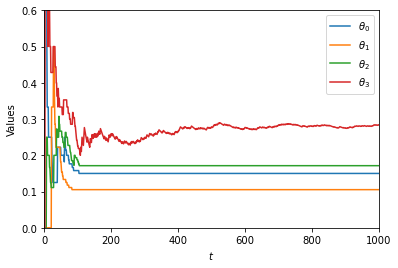

In [392]:
agent = SoftmaxAgent()
budget = 1000

value_snapshots = np.zeros((1000, 4))
rewards = np.zeros(1000)

for t in range(budget):
    arm = agent.get_arm()
    reward = Env.react(arm)
    agent.sample(arm, reward)

    rewards[t] = reward
    value_snapshots[t, :] = agent.values.copy()

plt.plot(value_snapshots[:, 0], label=r'$\theta_0$')
plt.plot(value_snapshots[:, 1], label=r'$\theta_1$')
plt.plot(value_snapshots[:, 2], label=r'$\theta_2$')
plt.plot(value_snapshots[:, 3], label=r'$\theta_3$')

plt.xlim([0, 1000])
plt.ylim([0, 0.6])

plt.xlabel(r"$t$")
plt.ylabel("Values")
plt.legend()
plt.show()

# Thompson Sampling

In [396]:
class BernoulliThompsonSamplingAgent(object):
    def __init__(self):
        self.counts = [0 for _ in range(Env.n_arms)]
        self.wins = [0 for _ in range(Env.n_arms)]

    def get_arm(self):
        beta = lambda N, a: np.random.beta(a + 1, N - a + 1)
        result = [beta(self.counts[i], self.wins[i]) for i in range(Env.n_arms)]
        arm = result.index(max(result))
        return arm

    def sample(self, arm, reward):
        self.counts[arm] += 1
        self.wins[arm] = self.wins[arm] + reward


In [397]:
arms_ts, rewards_ts = sim(BernoulliThompsonSamplingAgent)

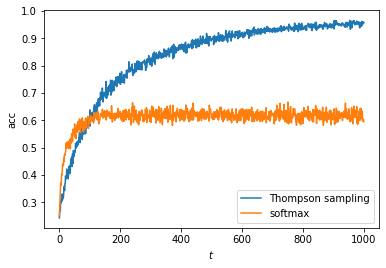

In [398]:
plt.plot(np.mean(arms_ts == Env.opt(), axis=0), label='Thompson sampling')
plt.plot(np.mean(arms_sm == Env.opt(), axis=0), label='softmax')
plt.xlabel(r'$t$')
plt.ylabel(r'acc')
plt.legend()
plt.show()